<a href="https://colab.research.google.com/github/jiminmini/mini/blob/ESAA_OB/10_6_%ED%95%84%EC%82%AC_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**[개념 정리]**

##**[텍스트 분석 실습- 전처리]**
- 로그 변환

##**[피처 인코딩과 피처 벡터화]**
- 선형 회귀: 원-핫 인코딩 적용 선호
- 희소 행렬 형태로 인코딩 적용

##**[릿지 회귀 모델 구축 및 평가]**
- 수행에 필요한 로직 함수화

##**[lightbgm 회귀 모델 구축 및 앙상블 이용]**
- n_estimaters를 1000 이상 증가시키면 예측 성능은 조금 좋아짐

#**[코드 필사]**

In [1]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd
import csv

mercari_df = pd.read_csv('mercari_train.tsv', sep='\t',quoting=csv.QUOTE_NONE, on_bad_lines='skip')
print(mercari_df.shape)
print(mercari_df.head(3))

(134391, 8)
   train_id                                 name  item_condition_id  \
0         0  MLB Cincinnati Reds T Shirt Size XL                  3   
1         1     Razer BlackWidow Chroma Keyboard                  3   
2         2                       AVA-VIV Blouse                  1   

                                       category_name brand_name  price  \
0                                  Men/Tops/T-shirts        NaN   10.0   
1  Electronics/Computers & Tablets/Components & P...      Razer   52.0   
2                        Women/Tops & Blouses/Blouse     Target   10.0   

   shipping                                   item_description  
0         1                                 No description yet  
1         0  This keyboard is in great condition and works ...  
2         1  Adorable top with a hint of lace and a key hol...  


In [2]:
print(mercari_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134391 entries, 0 to 134390
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   train_id           134391 non-null  int64  
 1   name               134391 non-null  object 
 2   item_condition_id  134391 non-null  int64  
 3   category_name      133841 non-null  object 
 4   brand_name         76815 non-null   object 
 5   price              134391 non-null  float64
 6   shipping           134391 non-null  int64  
 7   item_description   134391 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 8.2+ MB
None


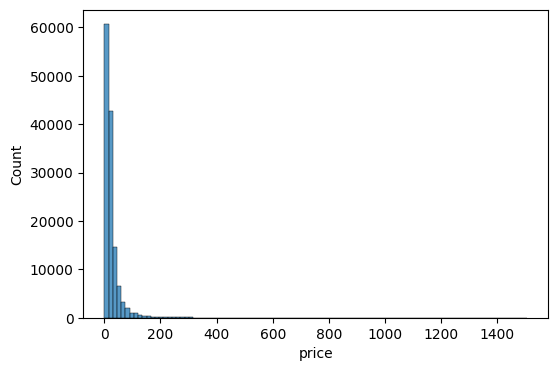

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
y_train_df = mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_train_df, bins=100)
plt.show()

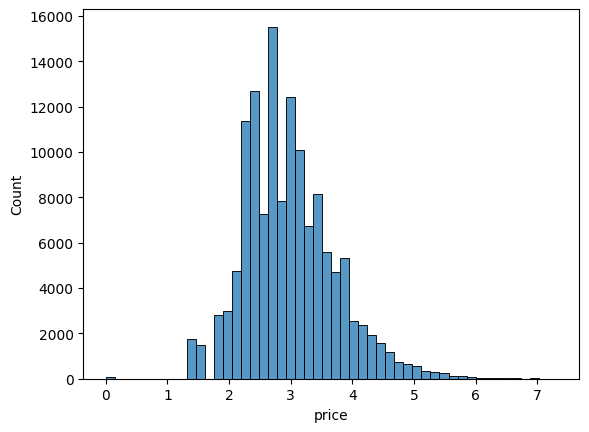

In [4]:
import numpy as np

y_train_df = np.log1p(y_train_df)
sns.histplot(y_train_df, bins=50)
plt.show()

In [5]:
mercari_df['price'] = np.log1p(mercari_df['price'])
mercari_df['price'].head(3)

,price
0,2.397895
1,3.970292
2,2.397895


In [6]:
print('Shipping 값 유형:\n', mercari_df['shipping'].value_counts())
print ('item_condition_id 값 유형: \n', mercari_df ['item_condition_id' ].value_counts())

Shipping 값 유형:
 shipping
0    74198
1    60193
Name: count, dtype: int64
item_condition_id 값 유형: 
 item_condition_id
1    57940
3    39132
2    34247
4     2854
5      218
Name: count, dtype: int64


In [7]:
boolean_cond= mercari_df['item_description']=='No description yet'
mercari_df[boolean_cond]['item_description'].count()

np.int64(7615)

In [9]:
# apply 1am으여에서 호출되는 대, 중, 소 분할 함수 생성, 대, 중, 소 값을 리스트로 반환
def split_cat(category_name):
    try:
        return category_name.split('/')
    except:
        return ['Other_Null', '0ther_Null', 'Other_Null']
 # 위의 split_cat( )을 apply lambda에서 호출해 대, 중, 소 칼럼을 mercari_df에 생성.
mercari_df ['cat_dae' ], mercari_df ['cat_jung'], mercari_df ['cat_so' ]=zip(*mercari_df['category_name'].apply(lambda x : split_cat(x)))
 # 대분류만 값의 유형과 건수를 살펴보고, 중분류, 소분류는 값의 유형이 많으므로 분류 개수만 추출
print('대분류 유형 :\n', mercari_df['cat_dae'].value_counts())
print('중분류 개수:', mercari_df[ 'cat_jung' ].nunique())
print('소분류 개수 ：', mercari_df['cat_so'].nunique())

대분류 유형 :
 cat_dae
Women                     60308
Beauty                    18905
Kids                      15618
Electronics               11107
Men                        8487
Home                       6112
Vintage & Collectibles     4156
Other                      4093
Handmade                   2785
Sports & Outdoors          2270
Other_Null                  550
Name: count, dtype: int64
중분류 개수: 112
소분류 개수 ： 725


In [10]:
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name' ] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')
# 각 칼럼별로 Null 값 건수 확인. 모두 0이 나와야 합니다.
mercari_df.isnull().sum()

,0
train_id,0
name,0
item_condition_id,0
category_name,0
brand_name,0
price,0
shipping,0
item_description,0
cat_dae,0
cat_jung,0


In [12]:
print('brand name 의 유형 건수 ：', mercari_df['brand_name'].nunique())
print('brand name sample 5건 : \n', mercari_df['brand_name'].value_counts()[:5])

brand name 의 유형 건수 ： 2324
brand name sample 5건 : 
 brand_name
Other_Null           57576
PINK                  4961
Nike                  4893
Victoria's Secret     4309
LuLaRoe               2822
Name: count, dtype: int64


In [13]:
print('name 의 종류 개수 ：', mercari_df['name'].nunique())
print('name sample 7건: \n', mercari_df['name'][:7])

name 의 종류 개수 ： 125181
name sample 7건: 
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: object


In [14]:
pd.set_option('max_colwidth', 200)
 # item_description의 평균 문자열 크기
print('item_description 평균 문자열 크기:', mercari_df['item_description'].str.len().mean())
mercari_df['item_description'][:2]

item_description 평균 문자열 크기: 145.56165963494578


,item_description
0,No description yet
1,This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.


In [17]:
 # name 속성에 대한 피처 벡터화 변환
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df.name)
 # item_description에 대한 피처 벡터화 변환
tfidf_descp = TfidfVectorizer(max_features = 50000, ngram_range= (1, 3), stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])
print('name vectorization shape：', X_name.shape)
print('item_description vectorization shape：', X_descp.shape)

name vectorization shape： (134391, 29518)
item_description vectorization shape： (134391, 50000)


In [23]:
from sklearn.preprocessing import LabelBinarizer
 # brand-name, item_condition_id, shipping 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_brand_name= LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])
lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])
lb_shipping= LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])
 # cat_dae, cat Jung, cat_so 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae= lb_cat_dae.fit_transform(mercari_df['cat_dae'])
lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_Jung = lb_cat_jung.fit_transform(mercari_df ['cat_jung' ])
lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

In [21]:
print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand shape：{0}, X_item_cond_id shape：{1}'.format(X_brand.shape, X_item_cond_id.shape))
print('X_shipping shape：{0}, X_cat_dae shape：{1}'.format(X_shipping.shape, X_cat_dae.shape))
print('X_cat_jung shape：{0}, X_cat_so shape：{1}'.format(X_cat_Jung.shape, X_cat_so.shape))

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand shape：(134391, 2324), X_item_cond_id shape：(134391, 5)
X_shipping shape：(134391, 1), X_cat_dae shape：(134391, 11)
X_cat_jung shape：(134391, 112), X_cat_so shape：(134391, 725)


In [24]:
from scipy.sparse import hstack
import gc
sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_Jung, X_cat_so)
 # hstack 함수를 이용해 인코딩과 벡터화를 수행한 데이터 세트를 모두 결합.
X_features_sparse= hstack(sparse_matrix_list).tocsr()
print(type(X_features_sparse), X_features_sparse.shape)
 # 데이터 세트가 메모리를 많이 차지하므로 사용 목적이 끝났으면 바로 메모리에서 삭제.
del X_features_sparse
gc.collect()

<class 'scipy.sparse._csr.csr_matrix'> (134391, 82696)


587

In [33]:
def rmsle(y, y_pred):
# underflow, overflow를 막기 위해 log가 아닌 loglp로 rmsle 계산
    return np.sqrt(np.mean(np.power(np.log1p(y) - np.log1p(y_pred), 2)))
def evaluate_org_price(y_test, preds):
# 원본 데이터는 loglp로 변환되었으므로 exmpml로 원복 필요.
    preds_exmpm = np.expm1(preds)
    y_test_exmpm = np.expm1(y_test)
 # rmsle로 RMSLE 값 추출
    rmsle_result = rmsle(y_test_exmpm, preds_exmpm)
    return rmsle_result

In [31]:
import gc
from scipy.sparse import hstack
def model_train_predict(model, matrix_list):
# scipy.sparse 모듈의 hstack을 이용해 희소 행렬 결합
    X= hstack(matrix_list).tocsr()
    X_train, X_test, y_train, y_test=train_test_split(X, mercari_df['price'], test_size=0.2, random_state=156)
 # 모델 학습 및 예측
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    del X, X_train, X_test, y_train
    gc.collect()
    return preds, y_test

In [34]:
linear_model = Ridge(solver = "lsqr", fit_intercept=False)
sparse_matrix_list = (X_name, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_Jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model,matrix_list=sparse_matrix_list)
print('Item Description을 제외했을 때 rmsle 값:', evaluate_org_price(y_test, linear_preds))
sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_Jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 포함한 rmsle 값:', evaluate_org_price(y_test, linear_preds))

Item Description을 제외했을 때 rmsle 값: 0.5305819313086919
Item Description을 포함한 rmsle 값: 0.5153896819479346


In [35]:
from lightgbm import LGBMRegressor
sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_Jung, X_cat_so)
lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.5, num_leaves=125, random_state=156)
lgbm_preds, y_test = model_train_predict(model = lgbm_model, matrix_list=sparse_matrix_list)
print('LightGBM rmsle 값:', evaluate_org_price(y_test, lgbm_preds))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 26.135211 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 501973
[LightGBM] [Info] Number of data points in the train set: 107512, number of used features: 19213
[LightGBM] [Info] Start training from score 2.977959


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM rmsle 값: 0.5360545852102812


In [36]:
preds = lgbm_preds * 0.45 + linear_preds * 0.55
print('LightGBM과 Ridge를 ensemble한 최종 rmsle 값:', evaluate_org_price(y_test, preds))

LightGBM과 Ridge를 ensemble한 최종 rmsle 값: 0.4978682253043892
